In [1]:
#Cell 1: Imports

import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_recall_fscore_support
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")
print(f"TensorFlow version: {tf.__version__}")
print("Mode: INCEPTION V3 WITHOUT TRANSFER LEARNING")


Imports successful.
TensorFlow version: 2.19.0
Mode: INCEPTION V3 WITHOUT TRANSFER LEARNING


In [2]:
#Cell 2: Configuration Parameters

GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

# InceptionV3 optimal input size is 299x299 (not 224x224)
IMG_SIZE = (299, 299)
BATCH_SIZE = 128  # Smaller batch size for InceptionV3 (memory intensive)
NUM_CLASSES = 4
EPOCHS = 100
LEARNING_RATE = 1e-4

SEED = 42
BEST_MODEL_SAVE_PATH = '/content/drive/MyDrive/inceptionv3_w_o_TL_best.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")
print(f"Mode: INCEPTION V3 WITHOUT TRANSFER LEARNING")
print(f"Image Size: {IMG_SIZE} (optimal for InceptionV3)")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")


Configuration parameters set.
Mode: INCEPTION V3 WITHOUT TRANSFER LEARNING
Image Size: (299, 299) (optimal for InceptionV3)
Epochs: 100
Learning Rate: 0.0001


In [3]:
#Cell 3: Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

if not os.path.exists(DATA_DIR):
    print(f"Copying {GDRIVE_ZIP_PATH} to local storage...")
    shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

    if os.path.exists(LOCAL_UNZIP_DIR):
        shutil.rmtree(LOCAL_UNZIP_DIR)
    os.makedirs(LOCAL_UNZIP_DIR)

    print(f"Extracting {LOCAL_ZIP_PATH}...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
        z.extractall(LOCAL_UNZIP_DIR)
else:
    print("Data already extracted.")

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset ready.")


Mounted at /content/drive
Copying /content/drive/MyDrive/AD_Dataset_compressed.zip to local storage...
Extracting /content/Data.zip...
Dataset ready.


In [4]:
#Cell 4: Load Dataset & Split (80/10/10)

full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes found:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

# Ensure at least 1 batch for val and test
if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"\nDataset splits:")
print(f"Total batches: {total_batches}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")


Found 86437 files belonging to 4 classes.
Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Dataset splits:
Total batches: 676
Training batches: 540
Validation batches: 67
Test batches: 69


In [5]:
#Cell 5: Calculate Class Weights & Data Augmentation

# Calculate class weights for handling imbalance
train_label_list = []
for _, lbl in train_dataset:
    train_label_list.extend(lbl.numpy())
train_label_array = np.array(train_label_list)

unique_classes = np.unique(train_label_array)
weights = compute_class_weight('balanced', classes=unique_classes, y=train_label_array)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, weights)}
print("Class weights:", class_weight_dict)
print(f"Class mapping: {dict(zip(unique_classes, class_names))}")

# Data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# InceptionV3 preprocessing: scales to [-1, 1]
def inception_preprocess(image, label):
    return tf.keras.applications.inception_v3.preprocess_input(image), label

# Apply augmentation and preprocessing to training data
train_dataset_processed = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)
train_dataset_processed = train_dataset_processed.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

# Apply preprocessing to validation and test data (no augmentation)
val_dataset_processed = val_dataset.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

test_dataset_processed = test_dataset.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

# Cache and prefetch for performance
train_dataset_processed = train_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset_processed = val_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset_processed = test_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)

print("\nData preprocessing and augmentation configured.")


Class weights: {0: 4.3680485338725985, 1: 45.23560209424084, 2: 0.32106426859404325, 3: 1.5764984946628957}
Class mapping: {np.int32(0): 'Mild Dementia', np.int32(1): 'Moderate Dementia', np.int32(2): 'Non Demented', np.int32(3): 'Very mild Dementia'}

Data preprocessing and augmentation configured.


In [6]:
#Cell 6: Define Focal Loss Function

def focal_loss_fn(alpha=0.25, gamma=2.5):
    """
    Focal Loss for handling class imbalance.
    Focuses learning on hard examples.

    Args:
        alpha: Weighting factor for rare class (default: 0.25)
        gamma: Focusing parameter (default: 2.5)

    Returns:
        Focal loss function
    """
    def focal_loss(y_true, y_pred):
        # Convert sparse labels to one-hot encoding
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        # Clip predictions to avoid numerical instability
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)
        # Calculate weighting factor (focus on hard examples)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        # Calculate focal loss
        loss = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
    return focal_loss

print("Focal Loss function defined (alpha=0.25, gamma=2.5)")


Focal Loss function defined (alpha=0.25, gamma=2.5)


In [7]:
#Cell 7: Build InceptionV3 Model WITHOUT Transfer Learning

print("Building InceptionV3 WITHOUT Transfer Learning...")
print("="*80)

# Base model WITHOUT ImageNet weights (weights=None)
base_model = InceptionV3(
    weights=None,  # No pretrained weights - training from scratch
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = True  # All layers trainable

# Build custom head (SAME as Inception_v3 WITH TL for fair comparison)
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
# Apply InceptionV3 preprocessing (scales to [-1, 1])
x = tf.keras.applications.inception_v3.preprocess_input(x)
x = base_model(x, training=True)
x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

print(f"\nTotal trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("\nModel Summary:")
model.summary()


Building InceptionV3 WITHOUT Transfer Learning...

Total trainable parameters: 23,872,676

Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,909,156 (91.21 MB)

 Trainable params: 23,872,676 (91.07 MB)

 Non-trainable params: 36,480 (142.50 KB)

In [8]:
#Cell 8: Compile and Train Model

print("="*80)
print("TRAINING INCEPTION V3 WITHOUT TRANSFER LEARNING")
print("="*80)

# Compile model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss=focal_loss_fn(alpha=0.25, gamma=2.5),
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print(f"\nStarting training ({EPOCHS} epochs)...")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Best model will be saved to: {BEST_MODEL_SAVE_PATH}")
print("="*80)

# Train the model
history = model.fit(
    train_dataset_processed,
    epochs=EPOCHS,
    validation_data=val_dataset_processed,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, lr_scheduler],
    verbose=1
)

print("\n" + "="*80)
print("Training Complete!")
print("="*80)


TRAINING INCEPTION V3 WITHOUT TRANSFER LEARNING

Starting training (100 epochs)...
Learning Rate: 0.0001
Best model will be saved to: /content/drive/MyDrive/inceptionv3_w_o_TL_best.keras
Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.4463 - loss: 0.2117
Epoch 1: val_loss improved from inf to 0.07041, saving model to /content/drive/MyDrive/inceptionv3_w_o_TL_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 318s 474ms/step - accuracy: 0.4465 - loss: 0.2116 - val_accuracy: 0.7695 - val_loss: 0.0704 - learning_rate: 1.0000e-04
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7412 - loss: 0.0924
Epoch 2: val_loss did not improve from 0.07041
540/540 ━━━━━━━━━━━━━━━━━━━━ 203s 377ms/step - accuracy: 0.7413 - loss: 0.0924 - val_accuracy: 0.7695 - val_loss: 0.1429 - learning_rate: 1.0000e-04
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7619 - loss: 0.0823
Epoch 3: val_loss improved from 0.07041 to 0.06452, saving model to /content/drive/M

KeyboardInterrupt: 

In [9]:
#Cell 9: Final Evaluation

print("="*80)
print("FINAL EVALUATION (INCEPTION V3 WITHOUT TRANSFER LEARNING)")
print("="*80)

# Load best model
best_model = tf.keras.models.load_model(
    BEST_MODEL_SAVE_PATH,
    custom_objects={'focal_loss': focal_loss_fn(alpha=0.25, gamma=2.5)}
)

# Evaluate on all sets
print("\nEvaluating on training set...")
train_loss, train_acc = best_model.evaluate(train_dataset_processed, verbose=0)

print("Evaluating on validation set...")
val_loss, val_acc = best_model.evaluate(val_dataset_processed, verbose=0)

print("Evaluating on test set...")
test_loss, test_acc = best_model.evaluate(test_dataset_processed, verbose=0)

print("\n" + "="*80)
print("OVERALL PERFORMANCE")
print("="*80)
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nTraining Loss:   {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss:       {test_loss:.4f}")


FINAL EVALUATION (INCEPTION V3 WITHOUT TRANSFER LEARNING)

Evaluating on training set...
Evaluating on validation set...
Evaluating on test set...

OVERALL PERFORMANCE
Training Accuracy:   0.7787 (77.87%)
Validation Accuracy: 0.7695 (76.95%)
Test Accuracy:       0.7790 (77.90%)

Training Loss:   0.0609
Validation Loss: 0.0633
Test Loss:       0.0617


In [10]:
#Cell 10: Early Detection Focused Evaluation

print("\n" + "="*80)
print("EARLY DETECTION METRICS (Per-Class Performance)")
print("="*80)

# Get predictions
y_true = np.concatenate([y.numpy() for _, y in test_dataset_processed], axis=0)
y_pred_probs = best_model.predict(test_dataset_processed, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Calculate key metrics for early detection
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)

print("\n" + "="*80)
print("EARLY DETECTION KEY METRICS")
print("="*80)

# Find index for "Very mild Dementia" (early stage)
early_stage_idx = None
for i, name in enumerate(class_names):
    if 'Very mild' in name or 'very mild' in name:
        early_stage_idx = i
        break

if early_stage_idx is not None:
    early_stage_name = class_names[early_stage_idx]
    print(f"\n{early_stage_name} (Early Stage) Metrics:")
    print(f"  Precision: {precision[early_stage_idx]:.4f}")
    print(f"  Recall:    {recall[early_stage_idx]:.4f} (Most important for early detection)")
    print(f"  F1-Score:  {f1[early_stage_idx]:.4f}")
    print(f"  Support:   {support[early_stage_idx]}")

# Calculate macro and weighted averages
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"  Macro F1-Score: {macro_f1:.4f} (Balanced across all classes)")
print(f"  Weighted F1-Score: {weighted_f1:.4f} (Weighted by support)")

# Early stage sensitivity (combining Very Mild + Mild)
mild_idx = None
for i, name in enumerate(class_names):
    if 'Mild' in name and 'Very' not in name:
        mild_idx = i
        break

if early_stage_idx is not None and mild_idx is not None:
    early_stages_mask = (y_true == early_stage_idx) | (y_true == mild_idx)
    early_stages_true = y_true[early_stages_mask]
    early_stages_pred = y_pred[early_stages_mask]

    if len(early_stages_true) > 0:
        early_sensitivity = recall_score(early_stages_true, early_stages_pred,
                                          labels=[early_stage_idx, mild_idx],
                                          average='weighted')
        print(f"\nEarly Stage Sensitivity (Very Mild + Mild): {early_sensitivity:.4f}")



EARLY DETECTION METRICS (Per-Class Performance)

Detailed Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.0000    0.0000    0.0000       522
 Moderate Dementia     0.0000    0.0000    0.0000        52
      Non Demented     0.7790    1.0000    0.8758      6809
Very mild Dementia     0.0000    0.0000    0.0000      1358

          accuracy                         0.7790      8741
         macro avg     0.1947    0.2500    0.2189      8741
      weighted avg     0.6068    0.7790    0.6822      8741


EARLY DETECTION KEY METRICS

Very mild Dementia (Early Stage) Metrics:
  Precision: 0.0000
  Recall:    0.0000 (Most important for early detection)
  F1-Score:  0.0000
  Support:   1358

Overall Metrics:
  Macro F1-Score: 0.2189 (Balanced across all classes)
  Weighted F1-Score: 0.6822 (Weighted by support)

Early Stage Sensitivity (Very Mild + Mild): 0.0000


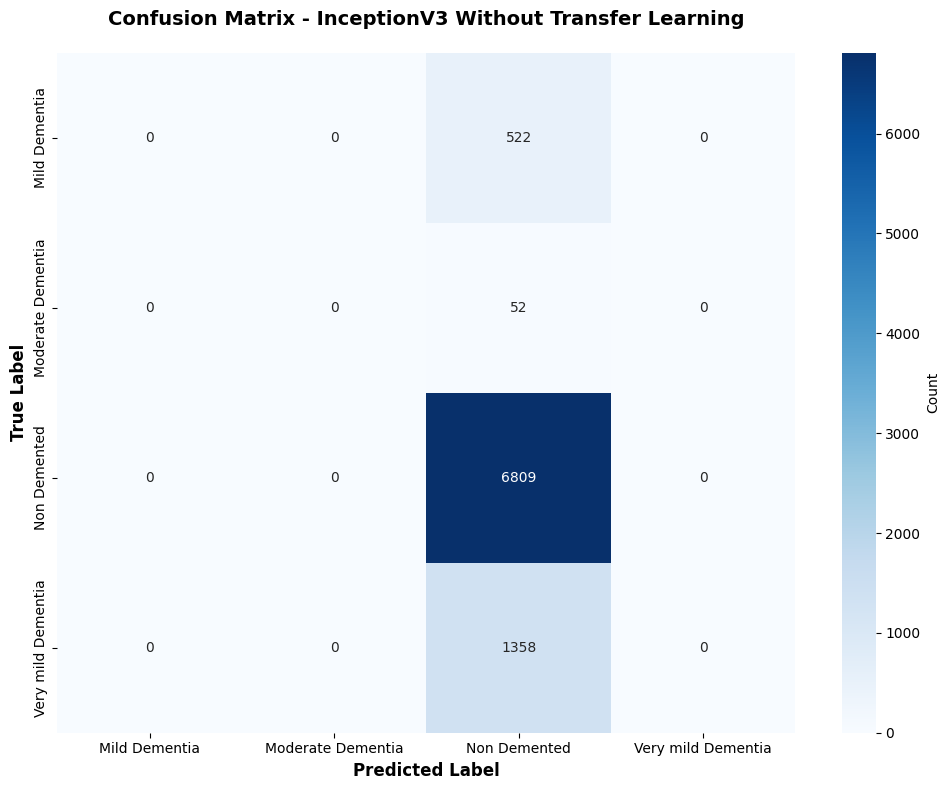

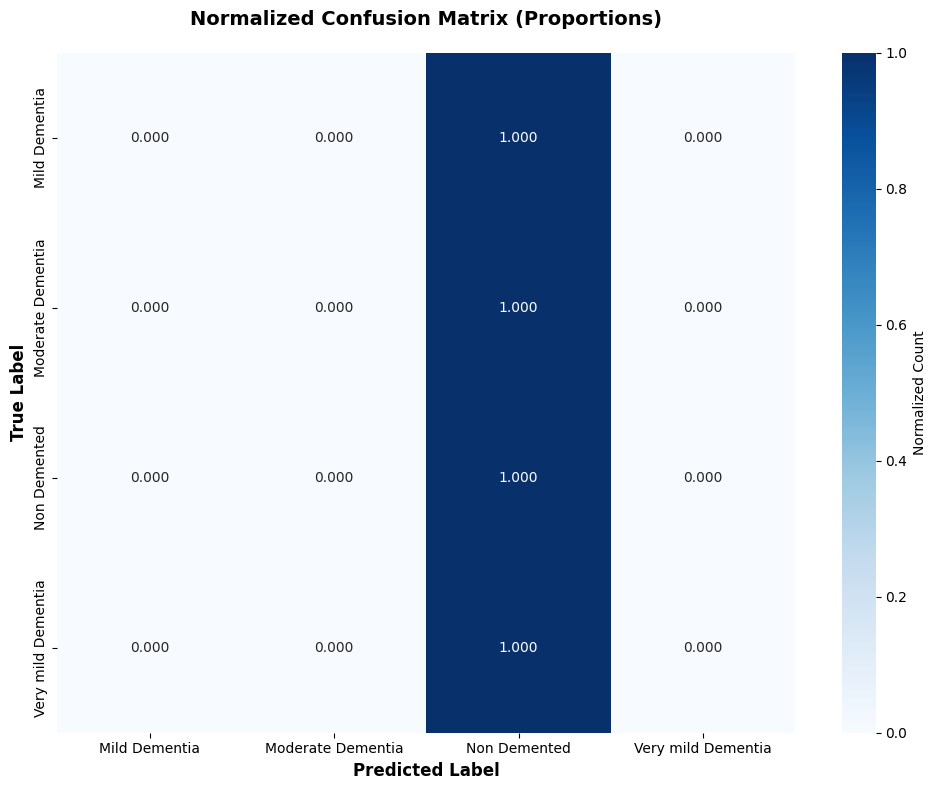

Confusion matrices plotted and saved.


In [11]:
#Cell 11: Confusion Matrix Visualization

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - InceptionV3 Without Transfer Learning',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inceptionv3_w_o_TL_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Normalized Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix (Proportions)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inceptionv3_w_o_TL_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices plotted and saved.")


NameError: name 'history' is not defined

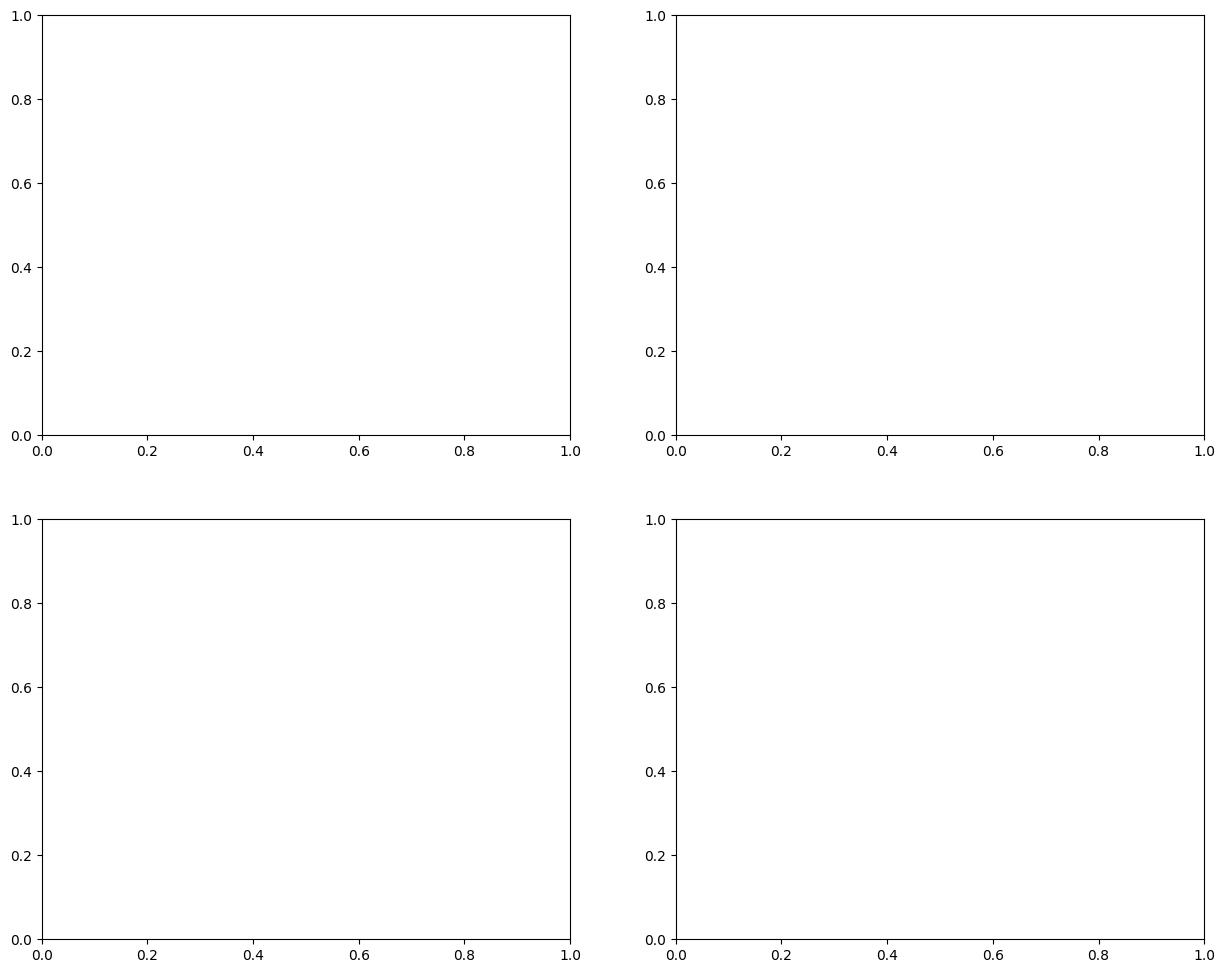

In [13]:
#Cell 12: Training Curves Visualization

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy curves
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss curves
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate (if available)
if 'lr' in history.history and len(history.history['lr']) > 0:
    axes[1, 0].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='green')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Learning rate history not available',
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')

# Per-class recall (for early detection focus)
class_recalls = []
for i, name in enumerate(class_names):
    if i < len(recall):
        class_recalls.append(recall[i])

axes[1, 1].bar(range(len(class_names)), class_recalls, color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181'])
axes[1, 1].set_xticks(range(len(class_names)))
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Per-Class Recall (Early Detection Focus)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(class_recalls):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inceptionv3_w_o_TL_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves and metrics visualization complete.")


In [14]:
#Cell 13: Save Model and Summary

# Save final model
best_model.save('/content/drive/MyDrive/inceptionv3_w_o_TL_final.keras')
print("Model saved to Google Drive.")

# Save summary to file
summary_text = f"""

INCEPTION V3 WITHOUT TRANSFER LEARNING - FINAL RESULTS


Configuration:
- Architecture: InceptionV3 (NO pretrained weights)
- Training Strategy: Training from scratch
- Epochs: {EPOCHS}
- Learning Rate: {LEARNING_RATE}
- Batch Size: {BATCH_SIZE}
- Image Size: {IMG_SIZE}
- Loss Function: Focal Loss (alpha=0.25, gamma=2.5)
- Class Weights: Applied for handling imbalance

Results:
- Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)
- Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)
- Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)

Per-Class Performance:
{classification_report(y_true, y_pred, target_names=class_names, digits=4)}

Key Metrics:
- Macro F1-Score: {macro_f1:.4f}
- Weighted F1-Score: {weighted_f1:.4f}

Early Detection Focus:
- Very Mild Dementia Recall: {recall[early_stage_idx]:.4f if early_stage_idx is not None else 'N/A'}

Comparison with Transfer Learning:
- InceptionV3 WITH TL: 94.05% test accuracy, 81.49% Very Mild Dementia recall
- InceptionV3 WITHOUT TL: {test_acc:.4f} test accuracy, {recall[early_stage_idx]:.4f if early_stage_idx is not None else 'N/A'} Very Mild Dementia recall
"""

print(summary_text)

# Save to file
with open('/content/drive/MyDrive/inceptionv3_w_o_TL_summary.txt', 'w') as f:
    f.write(summary_text)

print("\nSummary saved to Google Drive.")
print("\n" + "=" * 80)
print("EVALUATION COMPLETE!")
print("=" * 80)


Model saved to Google Drive.


ValueError: Invalid format specifier '.4f if early_stage_idx is not None else 'N/A'' for object of type 'float'